# CSV Parsing Robustness Evaluation

**CIDR 2027 submission figures.** This notebook summarizes system-level parsing
quality and analyzes errors by pollution category. Figures use a shared,
publication-oriented visual style and are exported at print resolution.

In [1]:
# Core analysis and plotting dependencies
from pathlib import Path
from IPython.display import HTML, display
import json
import re
import sys
import ast
from html import escape
from IPython.display import HTML


import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import PercentFormatter

In [2]:
# Shared CIDR-style figure theme
CIDR_DOUBLE_COLUMN = 7.00697
CIDR_SINGLE_COLUMN = 3.3374

CIDR_COLORS = {
    "navy": "#2E4A62",
    "burgundy": "#9E3D49",
    "teal": "#4F7C78",
    "gold": "#B58B3A",
    "slate": "#66717E",
    "light": "#E8EBEE",
    "text": "#252A30",
}

mpl.rcParams.update(
    {
        "figure.figsize": (CIDR_DOUBLE_COLUMN, 3.4),
        "figure.dpi": 150,
        "savefig.dpi": 300,
        "savefig.bbox": "tight",
        "font.family": "serif",
        "font.size": 9,
        "axes.titlesize": 10,
        "axes.titleweight": "semibold",
        "axes.labelsize": 9,
        "axes.edgecolor": "#A7ADB4",
        "axes.linewidth": 0.7,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "legend.fontsize": 8,
        "legend.frameon": False,
        "text.color": CIDR_COLORS["text"],
        "axes.labelcolor": CIDR_COLORS["text"],
        "xtick.color": CIDR_COLORS["text"],
        "ytick.color": CIDR_COLORS["text"],
    }
)

def find_repo_root() -> Path:
    """Locate the repository whether the notebook runs from root or its own folder."""
    start = Path.cwd().resolve()
    for candidate in (start, *start.parents):
        if (candidate / "eval" / "sut_error_summary.csv").exists():
            return candidate
    raise FileNotFoundError("Could not locate eval/sut_error_summary.csv")


REPO_ROOT = find_repo_root()

#TODO: replace sut error summary data with ... file 
#SUMMARY_PATH = REPO_ROOT / "eval" / "sut_error_summary.csv"
#SUMMARY_PATH = REPO_ROOT / "results" / "evaluation_summary_csv_storm.csv"
SUMMARY_PATH = REPO_ROOT / "results" / "evaluation_by_file_csv_storm.csv"

SUT_LABELS = {
    "clevercs": "CleverCSV",
    "csvcommons": "CSV Commons",
    "duckdbauto": "DuckDB Auto",
    "duckdbparse": "DuckDB Explicit",
    "mysql": "MySQL",
    "opencsv": "OpenCSV",
    "pandas": "Pandas",
    "postgres": "PostgreSQL",
    "pycsv": "Python csv",
    "rcsv": "R csv",
    "sqlite": "SQLite",
    "univocity": "UniVocity",
}


def display_sut_name(name: str) -> str:
    return SUT_LABELS.get(name, name.replace("_", " ").title())


def style_paper_axis(ax, *, grid_axis: str = "x") -> None:
    ax.grid(axis=grid_axis, color="#D8DCE0", linewidth=0.6, alpha=0.75)
    ax.set_axisbelow(True)
    ax.margins(x=0.01)


def select_top_suts(summary_data: pd.DataFrame, n: int = 5) -> list[str]:
    overall = summary_data.loc[summary_data["pollution_group"].eq("ALL")]
    return overall.nsmallest(n, "error_rate")["sut"].tolist()

### CSV Storm evaluation summary

Load and display the aggregate CSV Storm evaluation results.

In [3]:
CSV_STORM_SUMMARY_PATH = REPO_ROOT / "results" / "evaluation_summary_csv_storm.csv"
csv_storm_results = pd.read_csv(CSV_STORM_SUMMARY_PATH)

# Sorted by accuracy 
csv_storm_results = csv_storm_results.sort_values(by="accuracy",ascending=False)

# Remove SUTs that end with 'duckdb'
csv_storm_results = csv_storm_results[~csv_storm_results["sut"].str.endswith("duckdb", na=False)]

# Export as csv
csv_storm_results.to_csv("CIDR_submission_results.csv")
display(csv_storm_results)

,sut,success,header_precision,header_recall,header_f1,record_precision,record_recall,record_f1,cell_precision,cell_recall,cell_f1,pollock_simple,correct,wrong,accuracy,weighted_accuracy,pollock_weighted,score
3,clevercs,1.000000,0.809984,0.829308,0.814815,0.839193,0.832745,0.835885,0.908941,0.896226,0.902065,8.669161,38,31,0.550725,0.550725,8.669161,38
2,duckdbparse,1.000000,0.956522,0.952899,0.954451,0.866946,0.864908,0.865914,0.940509,0.961927,0.946782,9.310857,30,39,0.434783,0.434783,9.310857,30
0,duckdbauto_strict,0.985507,0.747182,0.726109,0.734403,0.813525,0.807865,0.810629,0.875623,0.852371,0.861674,8.214889,24,45,0.347826,0.347826,8.214889,24
4,pandas,0.985507,0.763285,0.782609,0.768116,0.779825,0.792437,0.781110,0.795607,0.833686,0.797416,8.079598,24,45,0.347826,0.347826,8.079598,24
1,pycsv,0.985507,0.835749,0.826897,0.813170,0.856853,0.850872,0.853784,0.931921,0.900074,0.904090,8.758917,7,62,0.101449,0.101449,8.758917,7


### Accuracy and Pollock Simple score for selected systems

The two metrics use separate panels to avoid a misleading dual-axis
comparison while retaining the original selected-system view.

In [4]:
def plot_sut_comparison(data: pd.DataFrame):
    """Plot accuracy and Pollock Simple score in a compact two-panel layout."""
    fig, axes = plt.subplots(
        1,
        2,
        figsize=(CIDR_DOUBLE_COLUMN, 2.8),
        constrained_layout=True,
    )

    specifications = [
        ("accuracy_pct", "Accuracy", CIDR_COLORS["navy"], (0, 100), "{:.1f}%"),
        ("pollock_simple", "Pollock Simple score", CIDR_COLORS["teal"], (9.5, 10.02), "{:.3f}"),
    ]
    x = np.arange(len(data))

    for ax, (column, title, color, limits, value_format) in zip(axes, specifications):
        bars = ax.bar(x, data[column], width=0.62, color=color)
        ax.set_title(title, loc="left")
        ax.set_xticks(x, data["SuT"])
        ax.set_ylim(*limits)
        style_paper_axis(ax, grid_axis="y")
        for bar, value in zip(bars, data[column]):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                value + (limits[1] - limits[0]) * 0.025,
                value_format.format(value),
                ha="center",
                va="bottom",
                fontsize=7.5,
            )

    axes[0].set_ylabel("Share of correctly parsed files")
    axes[0].yaxis.set_major_formatter(PercentFormatter(100))
    axes[1].set_ylabel("Score")
    return fig, axes

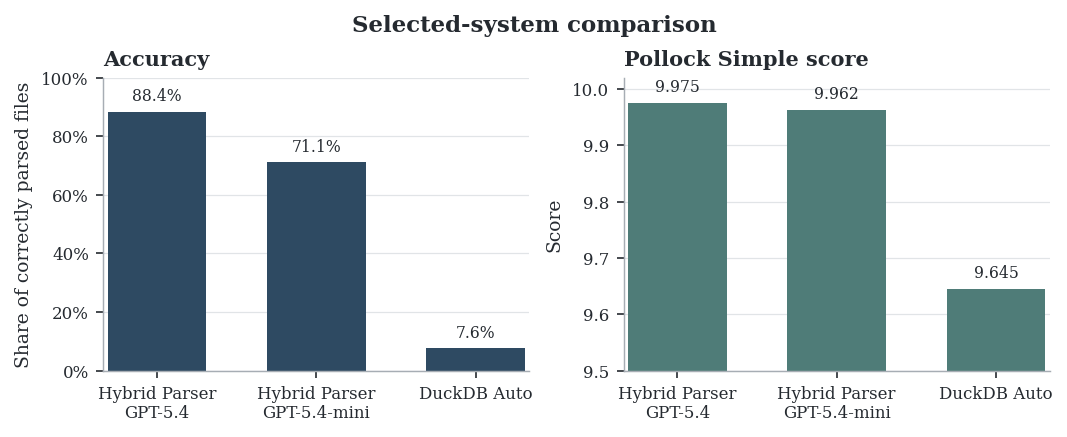

In [5]:
# TODO: read this from results file .csv, do not hardcode 

selected_systems = pd.DataFrame(
    {
        "SuT": [
            "Hybrid Parser\nGPT-5.4",
            "Hybrid Parser\nGPT-5.4-mini",
            "DuckDB Auto",
        ],
        "accuracy_pct": [88.3893, 71.0607, 7.6386],
        "pollock_simple": [9.975212, 9.962150, 9.645],
    }
)

fig, axes = plot_sut_comparison(selected_systems)
fig.suptitle("Selected-system comparison", fontsize=11, fontweight="semibold")
plt.show()

### Statistics per Pollution Category

In [6]:
# Derive CSV Storm pollution categories from the @pollution metadata.

def find_repo_root(start: Path) -> Path:
    """Find the repository root whether the notebook runs from root or its folder."""
    for candidate in (start, *start.parents):
        if (candidate / "pollution").is_dir() and (candidate / "results").is_dir():
            return candidate
    raise FileNotFoundError("Could not locate the Pollock repository root")


REPO_ROOT = find_repo_root(Path.cwd().resolve())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from pollution import polluters_stdlib_v1 as polluters_v1
from pollution import polluters_stdlib_v2 as polluters_v2


def recorded_csv_storm_model(sut_id: str) -> str:
    """Read the model identifier recorded by one CSV Storm LLM run."""
    run_dir = REPO_ROOT / "results" / sut_id / "csv_storm"
    time_path = run_dir / f"{sut_id}_time.csv"
    if time_path.exists():
        time_df = pd.read_csv(time_path)
        if "model" in time_df.columns:
            models = time_df["model"].dropna().astype(str).unique().tolist()
            if len(models) == 1:
                return models[0]
            if len(models) > 1:
                raise ValueError(f"Multiple models recorded in {time_path}: {models}")

    # The hybrid parser records its model in per-file LLM trace events.
    for trace_path in sorted((run_dir / "loading").glob("*.llm.jsonl")):
        with trace_path.open(encoding="utf-8") as trace_file:
            for line in trace_file:
                event = json.loads(line)
                if event.get("model"):
                    return str(event["model"])

    raise ValueError(f"No model metadata found for CSV Storm run: {sut_id}")


def display_model_name(model: str) -> str:
    """Format OpenAI model identifiers for publication labels."""
    return f"GPT-{model[4:]}" if model.lower().startswith("gpt-") else model

# Connect generated filenames to their polluter functions. The category and alias
# are then read from each function's decorator instead of duplicated here.
class CombinationPolluter:
    pollution_name = "Combination"
    pollution_category = "Combination"


FILENAME_POLLUTER_ROUTES = (
    (r"^combo__", CombinationPolluter),
    (r"^file_no_payload", polluters_v1.changeDimension),
    (r"^file_(no|double)_trailing_newline", polluters_v1.changeRowRecordDelimiter),
    (r"^file_(no_header|header_only|one_data_row)", polluters_v1.changeNumberRows),
    (r"^file_num_rows", polluters_v1.changeNumberRows),
    (r"^file_num_columns", polluters_v1.changeNumberColumns),
    (r"^file_header_multirow", polluters_v1.expandColumnHeader),
    (r"^file_preamble", polluters_v1.addPreamble),
    (r"^file_field_delimiter", polluters_v1.changeFieldDelimiter),
    (r"^file_quotation_char", polluters_v1.changeQuotationChar),
    (r"^file_escape_char", polluters_v1.changeEscapeCharacter),
    (r"^file_record_delimiter", polluters_v1.changeRecordDelimiter),
    (r"^row_quotation_mark", polluters_v1.changeRowQuotationMark),
    (r"^file_duplicate_header_as_data", polluters_v2.duplicateHeaderIntoRows),
    (r"^file_commented_row", polluters_v2.commentRow),
    (r"^file_more_columns", polluters_v2.moreColumns),
    (r"^file_less_columns_deleted_value", polluters_v2.lessColumnsDeletedValues),
    (r"^file_mixed_delimiters", polluters_v2.mixedDelimiters),
    (r"^file_multiline_header", polluters_v2.multilineHeader),
    (r"^file_superheader", polluters_v2.superheader),
    (r"^file_move_header", polluters_v2.moveHeaderRow),
    (r"^file_footnote", polluters_v2.addFootnote),
    (r"^file_extremely_long_field", polluters_v2.extremelyLongFields),
    (r"^file_unescaped", polluters_v2.unescapedMultiLineString),
    (r"^file_double_escaping", polluters_v2.doubleEscaping),
    (r"^file_unquoted_lists", polluters_v2.unquotedList),
    (r"^file_whitespace_delimiter_cells", polluters_v2.tableToWhitespaceFormattedTable),
    (r"^file_excel_autoformat", polluters_v2.excelExportAutoformat),
    (r"^file_excel_formulas", polluters_v2.spreadsheetFormulasInCSV),
    (r"^file_type_ambiguity", polluters_v2.typeAmbiguity),
    (r"^file_embedded_json", polluters_v2.embeddedJSON),
    (r"^file_embedded_csv", polluters_v2.embeddedCSV),
    (r"^file_mixed_time_formats", polluters_v2.mixedTimeformats),
    (r"^file_different_null_values", polluters_v2.differentNullValues),
)


def polluter_for_filename(filename: str):
    """Return the decorated polluter responsible for a CSV Storm filename."""
    for pattern, polluter in FILENAME_POLLUTER_ROUTES:
        if re.match(pattern, filename):
            return polluter
    return None


def pollution_category(filename: str) -> str:
    polluter = polluter_for_filename(filename)
    return polluter.pollution_category if polluter is not None else "Undefined"


def pollution_alias(filename: str) -> str:
    polluter = polluter_for_filename(filename)
    return polluter.pollution_name if polluter is not None else "Undefined"

### Per-file result explorer

Select a pollution and a system to inspect every recorded per-file metric for that combination. The summary above the table reports the number and share of fully correct files.

In [7]:
PER_FILE_RESULTS_PATH = REPO_ROOT / "results" / "evaluation_by_file_csv_storm.csv"
per_file_results = pd.read_csv(PER_FILE_RESULTS_PATH)
pollution_values = per_file_results["file"].map(pollution_alias).rename("pollution")
per_file_results = pd.concat([per_file_results, pollution_values], axis=1)

# A `<sut>_correct` column is present for every evaluated system and gives us
# an unambiguous list of SUT identifiers without hard-coding them here.
per_file_suts = sorted(
    column.removesuffix("_correct")
    for column in per_file_results.columns
    if column.endswith("_correct")
)
per_file_pollutions = sorted(
    pollution
    for pollution in per_file_results["pollution"].dropna().unique()
    if pollution != "Undefined"
)

explorer_payload = {
    "columns": per_file_results.columns.tolist(),
    "rows": json.loads(per_file_results.to_json(orient="records")),
    "suts": [
        {"id": sut, "label": display_sut_name(sut)}
        for sut in per_file_suts
    ],
    "pollutions": per_file_pollutions,
}
# Avoid accidentally closing the JSON script element if future data contains HTML.
explorer_json = json.dumps(explorer_payload).replace("</", "<" + chr(92) + "/")
explorer_id = "csv-storm-per-file-explorer"

explorer_html = f"""
<style>
  #{explorer_id} {{ font-family: sans-serif; color: #252A30; }}
  #{explorer_id} .controls {{ display: flex; gap: 16px; flex-wrap: wrap; margin: 8px 0 12px; }}
  #{explorer_id} label {{ display: flex; align-items: center; gap: 7px; font-weight: 600; }}
  #{explorer_id} select {{ min-width: 280px; padding: 5px 8px; }}
  #{explorer_id} .summary {{ margin: 8px 0; }}
  #{explorer_id} .table-wrap {{ max-height: 520px; overflow: auto; border: 1px solid #D8DCE0; }}
  #{explorer_id} table {{ border-collapse: collapse; width: max-content; min-width: 100%; font-size: 12px; }}
  #{explorer_id} th, #{explorer_id} td {{ border-bottom: 1px solid #E8EBEE; padding: 5px 8px; text-align: left; white-space: nowrap; }}
  #{explorer_id} th {{ position: sticky; top: 0; background: #F4F5F6; z-index: 1; }}
</style>
<div id="{explorer_id}">
  <div class="controls">
    <label>Pollution <select class="pollution-select"></select></label>
    <label>SUT <select class="sut-select"></select></label>
  </div>
  <div class="summary"></div>
  <div class="table-wrap"><table></table></div>
  <script type="application/json" class="explorer-data">{explorer_json}</script>
</div>
<script>
(() => {{
  const root = document.getElementById("{explorer_id}");
  const data = JSON.parse(root.querySelector(".explorer-data").textContent);
  const pollutionSelect = root.querySelector(".pollution-select");
  const sutSelect = root.querySelector(".sut-select");
  const summary = root.querySelector(".summary");
  const table = root.querySelector("table");

  function addOption(select, value, label) {{
    const option = document.createElement("option");
    option.value = value;
    option.textContent = label;
    select.appendChild(option);
  }}
  data.pollutions.forEach(value => addOption(pollutionSelect, value, value));
  data.suts.forEach(sut => addOption(sutSelect, sut.id, sut.label));

  function render() {{
    const pollution = pollutionSelect.value;
    const sut = sutSelect.value;
    const prefix = `${{sut}}_`;
    const metricColumns = data.columns.filter(column => column.startsWith(prefix));
    const rows = data.rows
      .filter(row => row.pollution === pollution)
      .sort((left, right) => left.file.localeCompare(right.file));
    const correctValues = rows
      .map(row => Number(row[`${{prefix}}correct`]))
      .filter(Number.isFinite);
    const correctCount = correctValues.reduce((total, value) => total + value, 0);
    const accuracy = correctValues.length ? correctCount / correctValues.length : 0;
    summary.innerHTML = `<b>${{rows.length}} files</b> &middot; <b>${{correctCount}} fully correct</b> &middot; <b>${{(100 * accuracy).toFixed(1)}}% accuracy</b>`;

    table.replaceChildren();
    const header = document.createElement("tr");
    ["file", ...metricColumns].forEach(column => {{
      const th = document.createElement("th");
      th.textContent = column === "file" ? column : column.slice(prefix.length);
      header.appendChild(th);
    }});
    const thead = document.createElement("thead");
    thead.appendChild(header);
    table.appendChild(thead);

    const tbody = document.createElement("tbody");
    rows.forEach(row => {{
      const tr = document.createElement("tr");
      ["file", ...metricColumns].forEach(column => {{
        const td = document.createElement("td");
        td.textContent = row[column] ?? "";
        tr.appendChild(td);
      }});
      tbody.appendChild(tr);
    }});
    table.appendChild(tbody);
  }}

  pollutionSelect.addEventListener("change", render);
  sutSelect.addEventListener("change", render);
  render();
}})();
</script>
"""
display(HTML(explorer_html))

In [8]:
# CSV Storm heatmap for the requested SUTs, in a fixed reporting order.
CSV_STORM_SUTS = [
    (
        "llm_hybrid_parser_gpt_5_6_sol",
        f"Hybrid Parser ({display_model_name(recorded_csv_storm_model('llm_hybrid_parser_gpt_5_6_sol'))})",
    ),
    (
        "full_llm_loader_naive_gpt_5_6_sol",
        f"Full LLM Parser ({display_model_name(recorded_csv_storm_model('full_llm_loader_naive_gpt_5_6_sol'))})",
    ),
    ("duckdbparse", "DuckDB Explicit"),
    ("duckdbauto_strict", "DuckDB Auto"),
    ("pandas", "Pandas"),
    ("pycsv", "Python csv"),
]

CATEGORY_ORDER = [
    "File Segmentation and Table-Boundary",
    "Header and Schema-Layout",
    "Dialect and Lexical-Syntax",
    "Record-Shape and Alignment",
    "Encoding and Text-Representation",
    "Value & Semantic Interpretation",
    "Operational Scale Stressor",
    "Combination",
    "Undefined",
]

CATEGORY_DISPLAY_LABELS = {
    "File Segmentation and Table-Boundary": "File Segmentation\n& Boundaries",
    "Header and Schema-Layout": "Header & Schema\nLayout",
    "Dialect and Lexical-Syntax": "Dialect & Lexical\nSyntax",
    "Record-Shape and Alignment": "Record Shape\n& Alignment",
    "Encoding and Text-Representation": "Encoding & Text\nRepresentation",
    "Value & Semantic Interpretation": "Value & Semantic\nInterpretation",
    "Operational Scale Stressor": "Operational Scale\nStressors",
    "Combination": "Combination",
    "Undefined": "Undefined",
}

def load_csv_storm_file_runtimes(sut_id: str) -> pd.DataFrame:
    """Load and summarize all recorded timing repetitions for each CSV file."""
    time_path = REPO_ROOT / "results" / sut_id / "csv_storm" / f"{sut_id}_time.csv"
    if not time_path.exists():
        return pd.DataFrame(columns=[
            "file", "runtime_mean_seconds", "runtime_median_seconds",
            "runtime_max_seconds", "runtime_repetitions",
        ])

    time_data = pd.read_csv(time_path)
    filename_column = "filename" if "filename" in time_data.columns else time_data.columns[0]
    time_columns = [
        column for column in time_data.columns
        if re.fullmatch(r"(?:.*_)?time_\d+", column)
    ]
    if not time_columns:
        raise ValueError(f"No timing columns found in {time_path}")

    timings = time_data[time_columns].apply(pd.to_numeric, errors="coerce")
    file_runtimes = pd.DataFrame({
        "file": time_data[filename_column].astype(str),
        "runtime_mean_seconds": timings.mean(axis=1),
        "runtime_median_seconds": timings.median(axis=1),
        "runtime_max_seconds": timings.max(axis=1),
        "runtime_repetitions": timings.notna().sum(axis=1),
    })
    if file_runtimes["file"].duplicated().any():
        duplicates = sorted(file_runtimes.loc[file_runtimes["file"].duplicated(), "file"].unique())
        raise ValueError(f"Duplicate filenames in {time_path}: {duplicates}")
    return file_runtimes


result_frames = []
for sut_id, sut_label in CSV_STORM_SUTS:
    result_dir = REPO_ROOT / "results" / sut_id / "csv_storm"
    result_candidates = [
        result_dir / f"{sut_id}_results.csv",
        result_dir / f"{sut_id}_results_incl_origin.csv",
    ]
    result_path = next((path for path in result_candidates if path.exists()), None)
    if result_path is None:
        raise FileNotFoundError(f"No CSV Storm results found for {sut_id}: {result_candidates}")
    sut_results = pd.read_csv(result_path)
    correct_column = f"{sut_id}_correct"
    required_columns = {"file", correct_column}
    missing_columns = required_columns.difference(sut_results.columns)
    if missing_columns:
        raise ValueError(f"{result_path} is missing columns: {sorted(missing_columns)}")

    # source.csv is the unpolluted baseline, not a heatmap pollution observation.
    sut_results = sut_results.loc[sut_results["file"] != "source.csv", ["file", correct_column]].copy()
    sut_results = sut_results.rename(columns={correct_column: "correct"})
    sut_results = sut_results.merge(
        load_csv_storm_file_runtimes(sut_id),
        on="file",
        how="left",
        validate="one_to_one",
    )
    sut_results["sut_id"] = sut_id
    sut_results["sut"] = sut_label
    result_frames.append(sut_results)

csv_storm_df = pd.concat(result_frames, ignore_index=True)
csv_storm_df["polluter"] = csv_storm_df["file"].map(polluter_for_filename)

unmapped_files = sorted(csv_storm_df.loc[csv_storm_df["polluter"].isna(), "file"].unique())
if unmapped_files:
    raise ValueError(f"CSV Storm files without a polluter mapping: {unmapped_files}")

csv_storm_df["pollution_alias"] = csv_storm_df["file"].map(pollution_alias)
csv_storm_df["pollution_category"] = csv_storm_df["file"].map(pollution_category)

pollution_category_map = (
    csv_storm_df[["file", "pollution_alias", "pollution_category"]]
    .drop_duplicates()
    .sort_values(["pollution_category", "pollution_alias", "file"])
    .reset_index(drop=True)
)

# Each CSV Storm file contributes one binary correctness observation. Taking the
# mean therefore reports the percentage of fully correct files in each category.
category_scores = (
    csv_storm_df.groupby(["sut", "pollution_category"], as_index=False)["correct"]
    .mean()
)
category_scores["full_correctness_pct"] = 100 * category_scores["correct"]

sut_order = [label for _, label in CSV_STORM_SUTS]
present_categories = set(category_scores["pollution_category"])
category_order = [category for category in CATEGORY_ORDER if category in present_categories]
category_order.extend(sorted(present_categories.difference(category_order)))

heatmap_df = category_scores.pivot(
    index="sut",
    columns="pollution_category",
    values="full_correctness_pct",
).reindex(index=sut_order, columns=category_order)

# Keep the heatmap palette local so the shared notebook theme cannot alter it.
heatmap_cmap = LinearSegmentedColormap.from_list(
    "paper_reddish",
    ["#05051a", "#3b1f46", "#a61c5b", "#ef4444", "#f6c9ad", "#fff1e6"],
)
heatmap_cmap.set_bad("#d9d9d9")
masked_scores = np.ma.masked_invalid(heatmap_df.to_numpy(dtype=float))

fig_width = max(17.5, 2.45 * len(heatmap_df.columns))
fig, ax = plt.subplots(figsize=(fig_width, 5.6))
im = ax.imshow(
    masked_scores,
    cmap=heatmap_cmap,
    aspect="auto",
    vmin=0,
    vmax=100,
)

ax.set_xticks(np.arange(heatmap_df.shape[1]))
ax.set_yticks(np.arange(heatmap_df.shape[0]))
ax.set_xticklabels(
    [CATEGORY_DISPLAY_LABELS.get(category, category) for category in heatmap_df.columns],
    rotation=0,
    ha="center",
    fontsize=12.5,
)
ax.set_yticklabels(heatmap_df.index, fontsize=12.5)
ax.tick_params(axis="x", pad=8)

ax.set_xticks(np.arange(-0.5, heatmap_df.shape[1], 1), minor=True)
ax.set_yticks(np.arange(-0.5, heatmap_df.shape[0], 1), minor=True)
ax.grid(False)
ax.grid(which="minor", color="white", linestyle="-", linewidth=1)
ax.tick_params(which="minor", bottom=False, left=False)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_xlabel("Pollution Category", fontsize=13.5, labelpad=18)
ax.set_ylabel("System", fontsize=13.5)
#ax.set_title("CSV Storm: Full Correctness by Pollution Category", fontsize=16, pad=14)

for row_idx in range(heatmap_df.shape[0]):
    for col_idx in range(heatmap_df.shape[1]):
        value = heatmap_df.iloc[row_idx, col_idx]
        if pd.isna(value):
            label, color = "—", "#555555"
        else:
            label = f"{value:.1f}"
            color = "black" if value >= 65 else "white"
        ax.text(
            col_idx,
            row_idx,
            label,
            ha="center",
            va="center",
            color=color,
            fontsize=13,
        )

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Full Correctness (%)", fontsize=12.5)

plt.tight_layout()
fig.subplots_adjust(bottom=0.22)
plt.savefig(REPO_ROOT / "eval" / "CIDR_plots" / "error_heatmap.png", dpi=300)
plt.show()

ValueError: No model metadata found for CSV Storm run: llm_hybrid_parser_gpt_5_6_sol

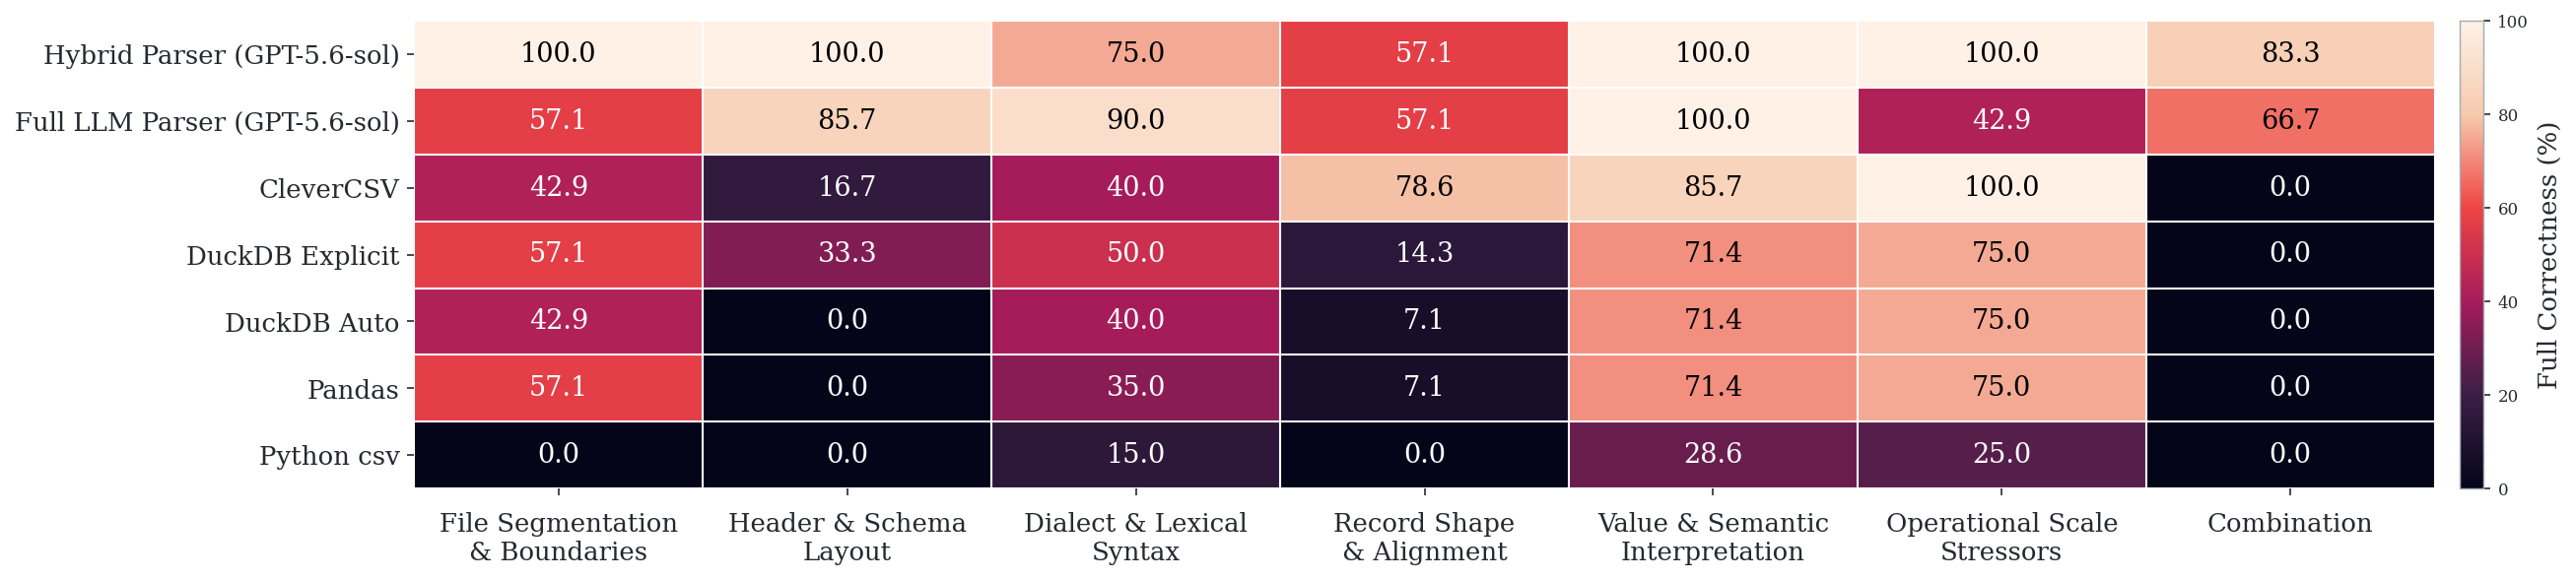

In [11]:
# Same heatmap as above, but the LLM rows are hardcoded from the reported run so the
# figure renders on a machine without LLM results on disk. The non-LLM rows are still
# computed from results/. Self-contained on purpose: the cell above raises before it
# defines heatmap_cmap when the LLM result folders are missing.
FIGURE_CATEGORIES = [
    "File Segmentation and Table-Boundary",
    "Header and Schema-Layout",
    "Dialect and Lexical-Syntax",
    "Record-Shape and Alignment",
    "Value & Semantic Interpretation",
    "Operational Scale Stressor",
    "Combination",
]

FIGURE_CATEGORY_LABELS = {
    "File Segmentation and Table-Boundary": "File Segmentation\n& Boundaries",
    "Header and Schema-Layout": "Header & Schema\nLayout",
    "Dialect and Lexical-Syntax": "Dialect & Lexical\nSyntax",
    "Record-Shape and Alignment": "Record Shape\n& Alignment",
    "Value & Semantic Interpretation": "Value & Semantic\nInterpretation",
    "Operational Scale Stressor": "Operational Scale\nStressors",
    "Combination": "Combination",
}

# Percentages transcribed from the reported CSV Storm run, in FIGURE_CATEGORIES order.
HARDCODED_LLM_SCORES = {
    "Hybrid Parser (GPT-5.6-sol)": [100.0, 100.0, 75.0, 57.1, 100.0, 100.0, 83.3],
    "Full LLM Parser (GPT-5.6-sol)": [57.1, 85.7, 90.0, 57.1, 100.0, 42.9, 66.7],
}

LOCAL_SUTS = [
    ("clevercs", "CleverCSV"),
    ("duckdbparse", "DuckDB Explicit"),
    ("duckdbauto_strict", "DuckDB Auto"),
    ("pandas", "Pandas"),
    ("pycsv", "Python csv"),
]

ROW_ORDER = [*HARDCODED_LLM_SCORES, *(label for _, label in LOCAL_SUTS)]

local_frames = []
for sut_id, sut_label in LOCAL_SUTS:
    result_dir = REPO_ROOT / "results" / sut_id / "csv_storm"
    result_path = next(
        (
            path
            for path in (
                result_dir / f"{sut_id}_results.csv",
                result_dir / f"{sut_id}_results_incl_origin.csv",
            )
            if path.exists()
        ),
        None,
    )
    if result_path is None:
        raise FileNotFoundError(f"No CSV Storm results found for {sut_id} in {result_dir}")

    sut_results = pd.read_csv(result_path)
    correct_column = f"{sut_id}_correct"
    if correct_column not in sut_results.columns:
        raise ValueError(f"{result_path} is missing column: {correct_column}")

    # source.csv is the unpolluted baseline, not a heatmap pollution observation.
    sut_results = sut_results.loc[sut_results["file"] != "source.csv", ["file", correct_column]]
    sut_results = sut_results.rename(columns={correct_column: "correct"})
    sut_results["sut"] = sut_label
    local_frames.append(sut_results)

local_scores = pd.concat(local_frames, ignore_index=True)
local_scores["pollution_category"] = local_scores["file"].map(pollution_category)
local_scores = (
    local_scores.groupby(["sut", "pollution_category"])["correct"].mean().mul(100).unstack()
)

paper_heatmap_df = pd.concat(
    [
        pd.DataFrame.from_dict(
            HARDCODED_LLM_SCORES, orient="index", columns=FIGURE_CATEGORIES
        ),
        local_scores,
    ]
).reindex(index=ROW_ORDER, columns=FIGURE_CATEGORIES)

paper_cmap = LinearSegmentedColormap.from_list(
    "paper_reddish",
    ["#05051a", "#3b1f46", "#a61c5b", "#ef4444", "#f6c9ad", "#fff1e6"],
)
paper_cmap.set_bad("#d9d9d9")
masked_paper_scores = np.ma.masked_invalid(paper_heatmap_df.to_numpy(dtype=float))

fig_width = max(17.5, 2.45 * paper_heatmap_df.shape[1])
fig_height = 0.4 * paper_heatmap_df.shape[0] + 1.0
fig, ax = plt.subplots(figsize=(fig_width, fig_height))
im = ax.imshow(masked_paper_scores, cmap=paper_cmap, aspect="auto", vmin=0, vmax=100)

ax.set_xticks(np.arange(paper_heatmap_df.shape[1]))
ax.set_yticks(np.arange(paper_heatmap_df.shape[0]))
ax.set_xticklabels(
    [FIGURE_CATEGORY_LABELS.get(category, category) for category in paper_heatmap_df.columns],
    rotation=0,
    ha="center",
    fontsize=12.5,
)
ax.set_yticklabels(paper_heatmap_df.index, fontsize=12.5)
ax.tick_params(axis="x", pad=8)

ax.set_xticks(np.arange(-0.5, paper_heatmap_df.shape[1], 1), minor=True)
ax.set_yticks(np.arange(-0.5, paper_heatmap_df.shape[0], 1), minor=True)
ax.grid(False)
ax.grid(which="minor", color="white", linestyle="-", linewidth=1)
ax.tick_params(which="minor", bottom=False, left=False)
for spine in ax.spines.values():
    spine.set_visible(False)

for row_idx in range(paper_heatmap_df.shape[0]):
    for col_idx in range(paper_heatmap_df.shape[1]):
        value = paper_heatmap_df.iloc[row_idx, col_idx]
        if pd.isna(value):
            label, color = "—", "#555555"
        else:
            label = f"{value:.1f}"
            color = "black" if value >= 65 else "white"
        ax.text(col_idx, row_idx, label, ha="center", va="center", color=color, fontsize=13)

cbar = fig.colorbar(im, ax=ax, fraction=0.02, pad=0.012)
cbar.set_label("Full Correctness (%)", fontsize=12.5)

plt.tight_layout()
fig.subplots_adjust(bottom=0.12)
plt.savefig(REPO_ROOT / "eval" / "CIDR_plots" / "error_heatmap_paper.png", dpi=300)
plt.show()


### CSV Storm Pollution Inventory

Polluted CSV artifacts from `pollute_main.py` using `--polluters csv_storm --combinations` (without optional per-cell pollutions), grouped by category. Each standalone or combination output counts once; the original `source.csv` is reported separately.

In [ ]:
# Derive every CSV Storm polluted CSV artifact directly from pollute_main.py.

def _args_attribute(test, attribute: str) -> bool:
    return (
        isinstance(test, ast.Attribute)
        and isinstance(test.value, ast.Name)
        and test.value.id == "args"
        and test.attr == attribute
    )


def _polluter_version_comparison(test):
    if not isinstance(test, ast.Compare) or len(test.ops) != 1 or len(test.comparators) != 1:
        return None
    if not isinstance(test.ops[0], ast.Eq) or not _args_attribute(test.left, "polluters"):
        return None
    comparator = test.comparators[0]
    return comparator.value if isinstance(comparator, ast.Constant) else None


def _static_iteration_length(iterator) -> int:
    """Return the output count for supported static loop iterators."""
    if (
        isinstance(iterator, ast.Call)
        and isinstance(iterator.func, ast.Name)
        and iterator.func.id == "range"
    ):
        try:
            arguments = [ast.literal_eval(argument) for argument in iterator.args]
            return len(range(*arguments))
        except (TypeError, ValueError):
            return 1

    if (
        isinstance(iterator, ast.Attribute)
        and isinstance(iterator.value, ast.Name)
        and iterator.value.id in {"pl", "pl2"}
    ):
        module = polluters_v1 if iterator.value.id == "pl" else polluters_v2
        value = getattr(module, iterator.attr, None)
        try:
            return len(value)
        except TypeError:
            return 1

    return 1


class CsvStormPolluterCollector(ast.NodeVisitor):
    """Follow CSV Storm branches and preserve every generated pollution call."""

    def __init__(self):
        self.polluters = []
        self.call_multiplier = 1

    def visit_If(self, node):
        version = _polluter_version_comparison(node.test)
        if version == "pollock1.0":
            selected_statements = node.orelse
        elif version == "csv_storm":
            selected_statements = node.body
        elif _args_attribute(node.test, "per_cell_pollutions"):
            # The standard CSV Storm generation does not pass --per-cell-pollutions.
            selected_statements = node.orelse
        else:
            selected_statements = [*node.body, *node.orelse]

        for statement in selected_statements:
            self.visit(statement)

    def visit_For(self, node):
        previous_multiplier = self.call_multiplier
        self.call_multiplier *= _static_iteration_length(node.iter)
        for statement in node.body:
            self.visit(statement)
        self.call_multiplier = previous_multiplier
        for statement in node.orelse:
            self.visit(statement)

    def visit_Call(self, node):
        if (
            isinstance(node.func, ast.Name)
            and node.func.id == "execute_polluter"
            and len(node.args) >= 2
            and isinstance(node.args[1], ast.Attribute)
            and isinstance(node.args[1].value, ast.Name)
            and node.args[1].value.id in {"pl", "pl2"}
        ):
            module_alias = node.args[1].value.id
            function_name = node.args[1].attr
            if function_name != "dummyPolluter":
                module = polluters_v1 if module_alias == "pl" else polluters_v2
                polluter = getattr(module, function_name)
                self.polluters.extend([polluter] * self.call_multiplier)
        elif isinstance(node.func, ast.Name) and node.func.id == "execute_polluter_combination":
            # Each combination call writes one polluted CSV artifact.
            self.polluters.extend([CombinationPolluter] * self.call_multiplier)
        self.generic_visit(node)


def _summarize_pollution_instances(values) -> str:
    counts = {}
    for value in values:
        counts[value] = counts.get(value, 0) + 1
    return ", ".join(
        f"{name} ×{count}" if count > 1 else name
        for name, count in counts.items()
    )


pollute_main_tree = ast.parse((REPO_ROOT / "pollute_main.py").read_text(encoding="utf-8"))
collector = CsvStormPolluterCollector()
collector.visit(pollute_main_tree)

active_csv_storm_polluters = collector.polluters
csv_storm_pollution_detail = pd.DataFrame(
    {
        "Instance": range(1, len(active_csv_storm_polluters) + 1),
        "Function": [polluter.__name__ for polluter in active_csv_storm_polluters],
        "Pollution": [polluter.pollution_name for polluter in active_csv_storm_polluters],
        "Category": [polluter.pollution_category for polluter in active_csv_storm_polluters],
    }
)

category_rank = {category: index for index, category in enumerate(CATEGORY_ORDER)}
csv_storm_pollution_table = (
    csv_storm_pollution_detail.groupby("Category", as_index=False, sort=False)
    .agg(
        Pollutions=("Pollution", _summarize_pollution_instances),
        Functions=("Function", "nunique"),
        Instances=("Pollution", "size"),
    )
    .assign(_rank=lambda frame: frame["Category"].map(category_rank).fillna(len(category_rank)))
    .sort_values(["_rank", "Category"])
    .drop(columns="_rank")
    .reset_index(drop=True)
)

total_pollution_functions = int(csv_storm_pollution_table["Functions"].sum())
total_pollution_instances = int(csv_storm_pollution_table["Instances"].sum())
total_csv_files = total_pollution_instances + 1  # Include source.csv.
inventory_rows_html = "".join(
    "<tr>"
    f"<td class='category'>{escape(str(row.Category))}</td>"
    f"<td>{escape(str(row.Pollutions))}</td>"
    f"<td class='count'>{int(row.Functions)}</td>"
    f"<td class='count'>{int(row.Instances)}</td>"
    "</tr>"
    for row in csv_storm_pollution_table.itertuples(index=False)
)
csv_storm_pollution_table_html = HTML(
    """
    <style>
      .csv-storm-inventory {
        border-collapse: collapse;
        font-size: 10.5pt;
        max-width: 1050px;
        line-height: 1.35;
      }
      .csv-storm-inventory th {
        background: #3b1f46;
        color: white;
        font-weight: 600;
        padding: 6px 10px;
        text-align: left;
      }
      .csv-storm-inventory td {
        border-bottom: 1px solid #eadde5;
        padding: 5px 10px;
        text-align: left;
        vertical-align: top;
      }
      .csv-storm-inventory .category {
        color: #3b1f46;
        font-weight: 600;
        min-width: 245px;
      }
      .csv-storm-inventory .count {
        text-align: center;
        width: 70px;
      }
      .csv-storm-inventory tfoot td {
        background: #f3edf1;
        border-top: 2px solid #3b1f46;
        color: #3b1f46;
        font-weight: 700;
      }
    </style>
    <table class="csv-storm-inventory">
      <thead><tr><th>Category</th><th>Polluted CSV artifacts</th><th>Pollution functions</th><th>Unique pollutions</th></tr></thead>
      <tbody>
    """
    + inventory_rows_html
    + "</tbody>"
    + "<tfoot><tr><td colspan='2'>Total</td>"
    + f"<td class='count'>{total_pollution_functions}</td>"
    + f"<td class='count'>{total_pollution_instances}</td></tr>"
    + "<tr><td colspan='3'>Total CSV files (+ original source.csv)</td>"
    + f"<td class='count'>{total_csv_files}</td></tr></tfoot></table>"
)
csv_storm_pollution_table_html

### Runtime and Cost by Pollution and SUT

Each file runtime is the mean of its recorded repetitions. The pollution and SUT summaries then treat each file as one observation, avoiding extra weight for files with more repetitions.

In [ ]:
# Collect per-file runtimes for every SUT in the overall CSV Storm summary.
runtime_frames = []
for sut_id in csv_storm_results["sut"].dropna().unique():
    sut_runtimes = load_csv_storm_file_runtimes(sut_id)
    sut_runtimes = sut_runtimes.loc[sut_runtimes["file"] != "source.csv"].copy()
    if sut_runtimes.empty:
        continue
    sut_runtimes["sut"] = sut_id
    sut_runtimes["pollution_alias"] = sut_runtimes["file"].map(pollution_alias)
    sut_runtimes["pollution_category"] = sut_runtimes["file"].map(pollution_category)
    runtime_frames.append(sut_runtimes)

csv_storm_runtime_by_file = pd.concat(runtime_frames, ignore_index=True)

pollution_runtime_summary = (
    csv_storm_runtime_by_file.groupby(
        ["sut", "pollution_category", "pollution_alias"],
        as_index=False,
    )
    .agg(
        timed_files=("file", "nunique"),
        total_seconds=("runtime_mean_seconds", "sum"),
        average_seconds=("runtime_mean_seconds", "mean"),
        median_seconds=("runtime_mean_seconds", "median"),
        max_seconds=("runtime_mean_seconds", "max"),
    )
    .sort_values(["sut", "pollution_category", "pollution_alias"])
    .reset_index(drop=True)
)

sut_runtime_summary = (
    csv_storm_runtime_by_file.groupby("sut", as_index=False)
    .agg(
        runtime_timed_files=("file", "nunique"),
        runtime_average_seconds=("runtime_mean_seconds", "mean"),
        runtime_median_seconds=("runtime_mean_seconds", "median"),
        runtime_max_seconds=("runtime_mean_seconds", "max"),
    )
    .sort_values("runtime_average_seconds")
    .reset_index(drop=True)
)

runtime_summary_columns = sut_runtime_summary.columns.drop("sut")
csv_storm_results = (
    csv_storm_results.drop(columns=runtime_summary_columns, errors="ignore")
    .merge(sut_runtime_summary, on="sut", how="left", validate="one_to_one")
)

display(pollution_runtime_summary)
display(sut_runtime_summary.sort_values(by="runtime_timed_files", ascending = False))

,sut,pollution_category,pollution_alias,timed_files,total_seconds,average_seconds,median_seconds,max_seconds
0,clevercs,Combination,Combination,6,0.142445,0.023741,0.021128,0.031309
1,clevercs,Dialect and Lexical-Syntax,Global Change of Escaping Strategy,2,0.050396,0.025198,0.025198,0.027411
2,clevercs,Dialect and Lexical-Syntax,Global Delimiter Change,4,0.108360,0.027090,0.024348,0.040318
3,clevercs,Dialect and Lexical-Syntax,Global Quote Character Change,2,0.052568,0.026284,0.026284,0.027260
4,clevercs,Dialect and Lexical-Syntax,Mixed Delimiters,3,0.063283,0.021094,0.020955,0.021478
...,...,...,...,...,...,...,...,...
385,pycsv,Value & Semantic Interpretation,Embedded JSON Structures,2,0.008759,0.004379,0.004379,0.004856
386,pycsv,Value & Semantic Interpretation,Embedded Sub-CSV Structures,1,0.005039,0.005039,0.005039,0.005039
387,pycsv,Value & Semantic Interpretation,Excel Autoformat Damage,1,0.004982,0.004982,0.004982,0.004982
388,pycsv,Value & Semantic Interpretation,Spreadsheet Formulas in CSV,1,0.004909,0.004909,0.004909,0.004909


,sut,runtime_timed_files,runtime_average_seconds,runtime_median_seconds,runtime_max_seconds
1,pandas,110,0.002645,0.001097,0.092996
2,duckdbauto,110,0.007766,0.005846,0.089413
8,pycsv,110,8.551600,0.005041,939.573221
3,code_generation_llm_gpt_5_4_mini,68,0.081930,0.021724,3.769017
4,clevercs,68,0.131536,0.021072,6.646747
5,code_generation_llm_gpt_5_6_luna,68,0.255907,0.193638,3.870000
0,duckdbparse,68,0.002293,0.001091,0.041041
6,llm_hybrid_parser_gpt_5_4_mini,68,0.334328,0.071536,8.704197
7,llm_hybrid_parser_gpt_5_6_luna,68,8.105533,3.730449,54.452576
9,llm_hybrid_parser_qwen3_5_0_8b,68,10.292936,0.092167,62.131287


In [ ]:
# Cost per 1M tokens 

OPENAI_MODEL_PRICING = {
    "gpt-5.4-mini":
        {"input": 0.75, "cached_input": 0.075, "output": 4.50,},
    "gpt-5.6-sol": 
        {"input": 5.00, "cached_input": 0.50, "output": 30.00,},
    "gpt-5.6-luna":
        {"input": 1.00, "cached_input": 0.10, "output": 6.00,},
    "gpt-5": {
        "input": 0.625, "cached_input": 0.0625, "output": 5.00,},
    "gpt-5.1": {
        "input": 0.625, "cached_input": 0.0625, "output": 5.00,},
    "gpt-5.2": {
        "input": 0.875, "cached_input": 0.0875, "output": 7.00,},
    "gpt-5-mini": {
        "input": 0.125, "cached_input": 0.0125, "output": 1.00,},
    "gpt-5-nano": {
        "input": 0.025, "cached_input": 0.0025, "output": 0.20,},
    "gpt-5-pro": {
        "input": 7.50, "cached_input": None, "output": 60.00,},
    "gpt-5.2-pro": {
        "input": 10.50, "cached_input": None, "output": 84.00,},
    "gpt-4.1": {
        "input": 1.00, "cached_input": None, "output": 4.00,},
    "gpt-4.1-mini": {
        "input": 0.20, "cached_input": None, "output": 0.80,},
    "gpt-4.1-nano": {
        "input": 0.05, "cached_input": None, "output": 0.20,
    },
    "gpt-4o": {
        "input": 1.25, "cached_input": None, "output": 5.00,},
    "gpt-4o-mini": {
        "input": 0.075, "cached_input": None, "output": 0.30,},
}

In [ ]:
def calc_openai_runcost(model, uncached_input_tokens, cached_input_tokens, completion_tokens):
    """Calculates the total cost of an OpenAI API call."""

    pricing = OPENAI_MODEL_PRICING[model]

    input_price, cached_input_price, output_price = pricing["input"], pricing["cached_input"], pricing["output"]

    input_cost = uncached_input_tokens * input_price / 1_000_000
    output_cost = completion_tokens * output_price / 1_000_000

    if cached_input_price is None:
        # Models without cached pricing charge the normal input rate
        cached_input_cost = cached_input_tokens * input_price / 1_000_000
    else:
        cached_input_cost = cached_input_tokens * cached_input_price / 1_000_000

    return input_cost + cached_input_cost + output_cost

### Estimated cost per CSV Storm run

Costs below represent a fresh, uncached API run. Classical systems and local models cost $0. A missing value means that the historical run did not record token usage, so its cost cannot be reconstructed reliably.

In [ ]:
# Add one cost record for every SUT in csv_storm_results.
import re


def _model_from_sut_id(sut_id):
    for model in OPENAI_MODEL_PRICING:
        model_slug = model.replace("-", "_").replace(".", "_")
        if model_slug in sut_id:
            return model
    return "qwen3.5:0.8b" if "qwen" in sut_id else None


def summarize_csv_storm_run_cost(sut_id):
    time_path = REPO_ROOT / "results" / sut_id / "csv_storm" / f"{sut_id}_time.csv"
    model = _model_from_sut_id(sut_id)
    base = {"sut": sut_id, "model": model}

    if not time_path.exists():
        return {**base, "uncached_input_tokens": pd.NA, "cached_input_tokens": pd.NA,
                "completion_tokens": pd.NA, "estimated_cost_usd": np.nan,
                "cost_status": "time file not found"}

    time_data = pd.read_csv(time_path)
    if "model" in time_data:
        models = time_data["model"].dropna().astype(str).unique().tolist()
        if len(models) > 1:
            raise ValueError(f"Multiple models recorded in {time_path}: {models}")
        if models:
            model = models[0]
            base["model"] = model

    run_indices = sorted(
        int(match.group(1))
        for column in time_data.columns
        if (match := re.fullmatch(r"uncached_input_tokens_(\d+)", column))
    )
    if not run_indices:
        if model and model.startswith("qwen"):
            return {**base, "uncached_input_tokens": pd.NA, "cached_input_tokens": pd.NA,
                    "completion_tokens": pd.NA, "estimated_cost_usd": 0.0,
                    "cost_status": "local model (no API cost)"}
        if model in OPENAI_MODEL_PRICING:
            return {**base, "uncached_input_tokens": pd.NA, "cached_input_tokens": pd.NA,
                    "completion_tokens": pd.NA, "estimated_cost_usd": np.nan,
                    "cost_status": "token usage not recorded"}
        return {**base, "uncached_input_tokens": 0, "cached_input_tokens": 0,
                "completion_tokens": 0, "estimated_cost_usd": 0.0,
                "cost_status": "no LLM API usage"}

    token_types = ("uncached_input_tokens", "cached_input_tokens", "completion_tokens")
    token_totals = {
        token_type: int(sum(
            pd.to_numeric(time_data[f"{token_type}_{run_index}"], errors="coerce").fillna(0).sum()
            for run_index in run_indices
        ))
        for token_type in token_types
    }

    if model and model.startswith("qwen"):
        estimated_cost = 0.0
        status = "local model (no API cost)"
    else:
        if model not in OPENAI_MODEL_PRICING:
            raise KeyError(f"No pricing configured for model {model!r} in {time_path}")
        estimated_cost = calc_openai_runcost(model=model, **token_totals)
        status = "estimated from recorded tokens"

    return {**base, **token_totals, "estimated_cost_usd": estimated_cost,
            "cost_status": status}


csv_storm_costs = pd.DataFrame(
    summarize_csv_storm_run_cost(sut_id)
    for sut_id in csv_storm_results["sut"]
)
cost_columns = csv_storm_costs.columns.drop("sut")
csv_storm_results = (
    csv_storm_results.drop(columns=cost_columns, errors="ignore")
    .merge(csv_storm_costs, on="sut", how="left", validate="one_to_one")
)

csv_storm_results[
    ["sut", "model","completion_tokens", "estimated_cost_usd", "cost_status"]]

,sut,model,completion_tokens,estimated_cost_usd,cost_status
0,llm_hybrid_parser_gpt_5_6_sol,gpt-5.6-sol,72036,12.402380,estimated from recorded tokens
1,llm_hybrid_parser_gpt_5_6_luna,gpt-5.6-luna,73228,1.998614,estimated from recorded tokens
2,full_llm_loader_naive_gpt_5_6_sol,gpt-5.6-sol,437648,16.599168,estimated from recorded tokens
3,llm_hybrid_parser_gpt_5_4_mini,gpt-5.4-mini,10214,0.112124,estimated from recorded tokens
4,clevercs,NaN,0,0.000000,no LLM API usage
5,code_generation_llm_gpt_5_6_luna,gpt-5.6-luna,<NA>,NaN,token usage not recorded
6,code_generation_llm_gpt_5_6_sol,gpt-5.6-sol,<NA>,NaN,token usage not recorded
7,duckdbparse,NaN,0,0.000000,no LLM API usage
8,full_llm_loader_naive_gpt_5_4_mini,gpt-5.4-mini,381448,1.966646,estimated from recorded tokens
9,code_generation_llm_gpt_5_4_mini,gpt-5.4-mini,<NA>,NaN,token usage not recorded
